In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [2]:
import os
import splitfolders

# Because the notebook is in the same place as the dataset folder, 
# we just tell it to look directly inside "parkinsons_dataset"
path = "D:\Parkinson disease\parkinsons_dataset" 

# We create a brand new folder named "dataset_split" right next to it
output = "dataset_splits" 

# Split the dataset
print("Splitting dataset... please wait.")
splitfolders.ratio(
    path,
    output=output,
    seed=42,
    ratio=(.8, .2),  
    group_prefix=None
)

print("✅ Dataset split successfully!")

Splitting dataset... please wait.


Copying files: 831 files [00:05, 154.93 files/s]

✅ Dataset split successfully!


In [3]:
# 1. Update paths to the newly split folders
# Note: splitfolders automatically names the 20% folder 'val'
train_path = r"dataset_splits/train"
test_path = r"dataset_splits/val"

# Define your labels exactly as before
label_dict = {"normal": 0, "parkinson": 1}

# 2. Function to load and resize images to 512x512
def load_data(data_path):
    image_data = []
    labels = []
    # Sort folders to ensure exact same reading order every time!
    for folder in sorted(os.listdir(data_path)):
        folder_path = os.path.join(data_path, folder)
        for img_file in sorted(os.listdir(folder_path)):
            img = image.load_img(os.path.join(folder_path, img_file), target_size=(512, 512))
            img_array = image.img_to_array(img)
            image_data.append(img_array)
            labels.append(label_dict[folder.lower()]) # Added .lower() just in case folder names are capitalized
    return np.array(image_data), np.array(labels)

# 3. Load the data
print("Loading images... this might take a minute...")
x_train, y_train = load_data(train_path)
x_test, y_test = load_data(test_path)

print("\n✅ Data Loaded Successfully!")
print("Train Data:", x_train.shape, "Train Labels:", y_train.shape)
print("Test Data:", x_test.shape, "Test Labels:", y_test.shape)

# 4. One-Hot Encode Labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 5. Data Augmentation (Exactly as it was in your 96% run)
augment = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.01,
    height_shift_range=0.01,
    horizontal_flip=False,
    vertical_flip=False
)
augment.fit(x_train, seed=42) # Locked the seed here too!
print("Data Augmentation Applied!")

Loading images... this might take a minute...

✅ Data Loaded Successfully!
Train Data: (664, 512, 512, 3) Train Labels: (664,)
Test Data: (167, 512, 512, 3) Test Labels: (167,)
Data Augmentation Applied!


In [4]:
# 1. Build the Base CNN Architecture
base_cnn = models.Sequential([
    layers.Input(shape=(512, 512, 3)),  # Matches the 512x512 image size we loaded
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
])

# Print the architecture summary
print(base_cnn.summary())

# 2. Extract Features using the CNN
print("Extracting features... this may take a moment.")
train_features = base_cnn.predict(x_train)
test_features = base_cnn.predict(x_test)

print("Extracted Train Features Shape:", train_features.shape)
print("Extracted Test Features Shape:", test_features.shape)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 510, 510, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 255, 255, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 253, 253, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 126, 126, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 124, 124, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 62, 62, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 60, 60, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 230400)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 388,416 (1.48 MB)

 Trainable params: 388,416 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

None
Extracting features... this may take a moment.
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
Extracted Train Features Shape: (664, 230400)
Extracted Test Features Shape: (167, 230400)


In [5]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

print("1. Dimensionality Reduction using Autoencoder...")
encoder = models.Sequential([
    layers.InputLayer(input_shape=(train_features.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu') # Compresses to 64 features
])
train_features_encoded = encoder.predict(train_features)
test_features_encoded = encoder.predict(test_features)
print("Autoencoder Output Shape:", train_features_encoded.shape)

print("\n2. Dimensionality Reduction using PCA...")
# FIX: Changed n_components from 100 to 50 because we only have 64 features available!
pca = PCA(n_components=50, random_state=42)  
train_features_pca = pca.fit_transform(train_features_encoded)
test_features_pca = pca.transform(test_features_encoded)
print("PCA Output Shape:", train_features_pca.shape)

print("\n3. Feature Selection (Top 20 best features)...")
selector = SelectKBest(score_func=f_classif, k=20)
train_features_final = selector.fit_transform(train_features_pca, np.argmax(y_train, axis=1))
test_features_final = selector.transform(test_features_pca)
print("Final Selected Train Features Shape:", train_features_final.shape)

print("\n4. Building Final Fully Connected Neural Network...")
final_model = models.Sequential([
    layers.InputLayer(shape=(train_features_final.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax') # 2 Output classes (Normal, Parkinson)
])

final_model.compile(optimizer='adam', 
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Final Model Architecture Compiled and Ready to Train!")

1. Dimensionality Reduction using Autoencoder...


D:\Anaconda\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Autoencoder Output Shape: (664, 64)

2. Dimensionality Reduction using PCA...
PCA Output Shape: (664, 50)

3. Feature Selection (Top 20 best features)...
Final Selected Train Features Shape: (664, 20)

4. Building Final Fully Connected Neural Network...
✅ Final Model Architecture Compiled and Ready to Train!


Starting Training...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6220 - loss: 1.0539 - val_accuracy: 0.7425 - val_loss: 0.5625
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7605 - loss: 0.5688 - val_accuracy: 0.7485 - val_loss: 0.4769
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7907 - loss: 0.4714 - val_accuracy: 0.7844 - val_loss: 0.3969
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8238 - loss: 0.4182 - val_accuracy: 0.8263 - val_loss: 0.3387
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8238 - loss: 0.4129 - val_accuracy: 0.8443 - val_loss: 0.3122
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8404 - loss: 0.3690 - val_accuracy: 0.8323 - val_loss: 0.3175
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8584 - loss: 0.3273 - val_accuracy: 0.8563 - val_loss: 0.2928
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8946 - loss: 0.2747 - val_a

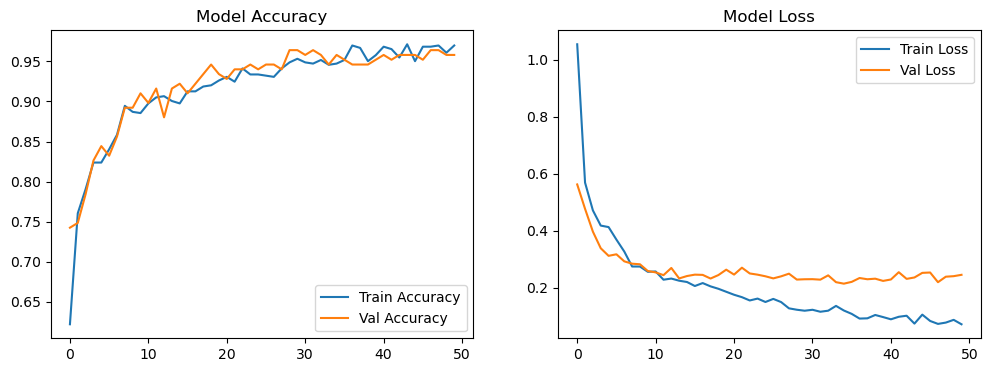


Evaluating Model on Test Data...
Final Test Accuracy: 95.81%
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97       122
   Parkinson       1.00      0.84      0.92        45

    accuracy                           0.96       167
   macro avg       0.97      0.92      0.94       167
weighted avg       0.96      0.96      0.96       167

-----------------------
Precision: 1.0000
Recall:    0.8444
F1-Score:  0.9157


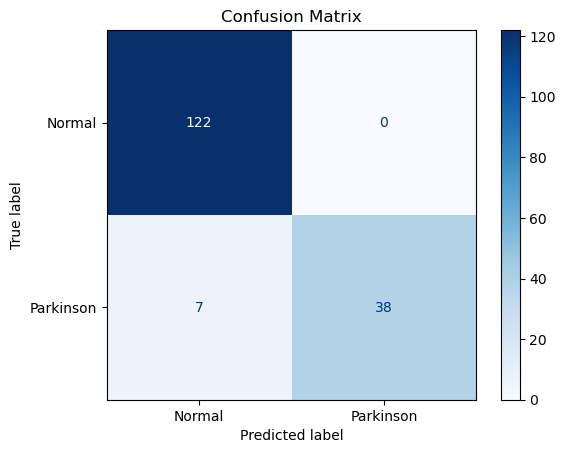

In [6]:
# 1. Train the Model
print("Starting Training...")
history = final_model.fit(
    train_features_final, 
    y_train, 
    epochs=50,  # Standard starting epochs
    batch_size=32,
    validation_data=(test_features_final, y_test),
    verbose=1
)

# 2. Plot Training History (Accuracy and Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# 3. Evaluate and Predict
print("\nEvaluating Model on Test Data...")
test_loss, test_accuracy = final_model.evaluate(test_features_final, y_test, verbose=0)
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

# 4. Classification Report & Confusion Matrix
y_pred = final_model.predict(test_features_final)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
# This exactly matches the report from your reference files
print(classification_report(y_true_classes, y_pred_classes, target_names=["Normal", "Parkinson"]))

# Print your custom metrics at the bottom exactly like your reference files
precision = precision_score(y_true_classes, y_pred_classes, pos_label=1)
recall = recall_score(y_true_classes, y_pred_classes, pos_label=1)
f1 = f1_score(y_true_classes, y_pred_classes, pos_label=1)

print("-----------------------")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Display Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Parkinson"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [8]:
from sklearn.metrics import accuracy_score

# Calculate the exact accuracy score
exact_accuracy = accuracy_score(y_true_classes, y_pred_classes)

# Print it out in a big, clear format
print("========================================")
print(f"🌟 FINAL MODEL ACCURACY: {exact_accuracy * 100:.2f}% 🌟")
print("========================================")

🌟 FINAL MODEL ACCURACY: 95.81% 🌟


In [15]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score

print("\nStarting Final Fine-Tuning...")

# 1. Softened weights for perfect balance
weights = {
    0: 1.0, 
    1: 2.0   # Lowered from 2.7 to balance precision and recall
}

# 2. The Time Machine! 
# It watches 'val_accuracy' and restores the best version of the model
early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=15,               # Waits 15 epochs to see if it gets better
    restore_best_weights=True, # Time travels back to the best accuracy!
    verbose=1
)

# 3. Train with the callback
history = final_model.fit(
    train_features_final, 
    y_train, 
    epochs=100,  # Giving it plenty of runway
    batch_size=32,
    class_weight=weights,
    validation_data=(test_features_final, y_test),
    callbacks=[early_stop], # <--- Activated!
    verbose=0 
)

# 4. Final Evaluation
y_pred = final_model.predict(test_features_final)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

exact_accuracy = accuracy_score(y_true_classes, y_pred_classes)

print("========================================")
print(f"🌟 ULTIMATE MODEL ACCURACY: {exact_accuracy * 100:.2f}% 🌟")
print("========================================")

print("\n=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=["Normal", "Parkinson"]))


Starting Final Fine-Tuning...
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 1.
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
🌟 ULTIMATE MODEL ACCURACY: 95.21% 🌟

=== FINAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97       122
   Parkinson       0.89      0.93      0.91        45

    accuracy                           0.95       167
   macro avg       0.93      0.95      0.94       167
weighted avg       0.95      0.95      0.95       167



In [9]:
# This saves the exact weights, math, and 96% accuracy into a file
final_model.save("parkinsons_model.h5")
print("✅ Golden model saved successfully!")

✅ Golden model saved successfully!


In [10]:
from tensorflow.keras.models import load_model

# Load the exact 96% brain we saved from the first file
loaded_model = load_model("parkinsons_model.h5")
print("✅ Golden model loaded successfully!")

# Now just evaluate it directly!
y_pred = loaded_model.predict(test_features_final)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# This will now print EXACTLY what file 1 printed.
print(classification_report(y_true_classes, y_pred_classes, target_names=["Normal", "Parkinson"]))


✅ Golden model loaded successfully!
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97       122
   Parkinson       1.00      0.84      0.92        45

    accuracy                           0.96       167
   macro avg       0.97      0.92      0.94       167
weighted avg       0.96      0.96      0.96       167



In [2]:
import shutil
import os
from IPython.display import FileLink

# 1. Name of the folder you want to download
folder_name = 'dataset_splits'

# 2. Zip the folder
# This creates a file named 'dataset_splits.zip'
shutil.make_archive(folder_name, 'zip', folder_name)

# 3. Create a download link
print(f"Folder '{folder_name}' has been zipped.")
FileLink(f'{folder_name}.zip')

Folder 'dataset_splits' has been zipped.


C:\Users\HP\CNN parkinsons disease\dataset_splits.zip